In [1]:
# Mount drive to access datasets

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Multi-class transistor anomaly classification with pre-split then augmented anomaly images

In [2]:
# Library imports

from pathlib import Path
import os
import cv2
import numpy as np
import pandas as pd

# Imports for visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Imports for ML
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.metrics import classification_report_imbalanced


In [14]:
# Imports for CNNs

# Imports for building the model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import LeakyReLU
# Imports for model training
from tensorflow.keras.callbacks import EarlyStopping

# Imports for image transformations
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import GlobalAveragePooling2D

# Importing the image_dataset_from_directory utility from Keras
from keras.utils import image_dataset_from_directory

# Importing loss function
from tensorflow.keras.losses import CategoricalCrossentropy

# Imports for using a pre-trained model Xception
from tensorflow.keras.applications.xception import preprocess_input

import tensorflow as tf


In [15]:
# Functions

def plot_training(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]

    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]

    plt.figure(figsize=(20, 8))

    # Plot the MSE loss
    plt.subplot(121)
    plt.plot(train_loss)
    plt.plot(val_loss)
    plt.title('Model Loss per Epoch (MSE)')
    plt.ylabel('Loss (MSE)')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')

    # Plot the Mean Absolute Error (MAE)
    plt.subplot(122)
    plt.plot(train_acc)
    plt.plot(val_acc)
    plt.title('Accuracy per Epoch')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')

    plt.show()


def get_predictions_and_labels(model, dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)


def plot_cm(y_true, y_pred):
    plt.figure(figsize=(10, 10))  # Create a large figure for the confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')  # Compute the normalized confusion matrix
    sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")  # Plot the confusion matrix as a heatmap
    plt.show()


def cm_bin(y_true, y_pred):
    cnf_matrix = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)

def deprocess_vgg16(x):
    # Reverses the preprocessing done by tf.keras.applications.vgg16.preprocess_input
    # x is a BGR array with mean subtracted
    x = x.copy()
    mean = [103.939, 116.779, 123.68]  # BGR mean values

    x[..., 0] += mean[0]
    x[..., 1] += mean[1]
    x[..., 2] += mean[2]

    # Convert BGR to RGB
    x = x[..., ::-1]

    x = np.clip(x, 0, 255).astype('uint8')
    return x

def grad_cam(image, model, layer_name):
    # Retrieve the convolutional layer
    layer = model.get_layer(layer_name)

    # Create a model that generates the outputs of the convolutional layer and the predictions
    grad_model = Model(inputs=model.input, outputs=[layer.output, model.output])

    # Add a batch dimension. Ensure the image passed to grad_model is float32 and preprocessed.
    # The 'image' input to this function (grad_cam) is already expected to be preprocessed float32.
    image_for_model = tf.expand_dims(image, axis=0)

    # Compute the gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_for_model) # Use image_for_model here
        predicted_class = tf.argmax(predictions[0])  # Predicted class
        # Ensure 'loss' is a scalar for tape.gradient
        loss = predictions[:, predicted_class]

    # Gradients of the scores with respect to the outputs of the convolutional layer
    grads = tape.gradient(loss, conv_outputs)

    # Weighted average of the gradients for each channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the activations by the calculated gradients
    conv_outputs = conv_outputs[0]  # Remove the batch dimension
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0)  # Focus only on positive values
    # Handle potential division by zero if heatmap is all zeros
    if tf.math.reduce_max(heatmap) > 0:
        heatmap /= tf.math.reduce_max(heatmap)  # Normalize between 0 and 1
    else:
        heatmap = tf.zeros_like(heatmap) # If all zeros, keep it as zeros
    heatmap = heatmap.numpy()  # Convert to numpy array for visualization

    # Resize the heatmap to match the original image size
    # Use image.shape[0] and image.shape[1] for height and width of the single image
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[0], image.shape[1])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)  # Remove the singleton dimension at the end of the heatmap_resized array

    return heatmap_resized, predicted_class.numpy()

def show_grad_cam_cnn(images, model, class_names):
    number_of_images = images.shape[0]
    # Get convolutional layers from the VGG16 base model, if it's the first layer of the model
    # Or directly from the VGG16 application if the model is built differently

    # Access the VGG16 model which is the first layer of `model`
    if isinstance(model.layers[0], tf.keras.Model) and model.layers[0].name == 'vgg16':
        base_vgg_model = model.layers[0]
        conv_layers = [layer.name for layer in base_vgg_model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    else:
        # Fallback if VGG16 is not the first layer or not named 'vgg16'
        # This might need adjustment based on how the VGG16 model is truly integrated
        conv_layers = [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]

    # Use only the last convolutional block's last layer for Grad-CAM for clarity
    if conv_layers: # Check if list is not empty
        # A typical VGG16 last conv layer is in block5_conv3 or similar
        target_conv_layer = [l for l in conv_layers if 'block5_conv3' in l or 'conv3' in l][-1] # Get last conv layer of the last block
    else:
        print("No convolutional layers found in the model.")
        return

    plt.figure(figsize=(4 * number_of_images, 5))

    for i in range(number_of_images):
        original_image_display = deprocess_vgg16(images[i])

        # Get the heatmap and predicted class from grad_cam function
        heatmap, predicted_class_idx = grad_cam(images[i], model, target_conv_layer)
        predicted_class_name = class_names[predicted_class_idx]

        # Convert heatmap to RGB
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        # Superimpose the heatmap on the original image
        superimposed_img = heatmap * 0.4 + original_image_display
        superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

        # Plotting
        plt.subplot(1, number_of_images, i + 1)
        plt.imshow(superimposed_img)
        plt.title(f'Predicted: {predicted_class_name}\nLayer: {target_conv_layer}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [16]:
# Callbacks for model training

early_stopping = EarlyStopping(
                                patience=5,
                                min_delta=0.01,
                                mode='min',
                                monitor='val_loss')


## Transfer learning with Xception for multi-class anomaly classification

In [6]:
# Datasets preparation (pre-split)

train_dir = '/content/drive/My Drive/Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor/train'
val_dir = '/content/drive/My Drive/Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor/validation'
holdout_dir = '/content/drive/My Drive/Colab Notebooks/anomalies_multi_class/split_val_test_before_augmentation/transistor/holdout'

train_ds = image_dataset_from_directory(
    train_dir,
    seed=42,
    batch_size=16,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224)  # Resize images for VGG16
)

val_ds = image_dataset_from_directory(
    val_dir,
    seed=42,
    batch_size=16,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224)  # Resize images for VGG16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=42,
    batch_size=16,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224)  # Resize images for VGG16
)

Found 975 files belonging to 5 classes.
Found 308 files belonging to 5 classes.
Found 103 files belonging to 5 classes.


In [7]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))


Xception model with pretrained layers accessible

In [17]:
import keras

inputs = Input(shape=(224, 224, 3))

base_model = tf.keras.applications.xception.Xception(include_top=False, pooling='avg', weights="imagenet", input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

output = Dense(5, activation='softmax')(base_model.output)
model_X = Model(base_model.input, output)

model_X.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [18]:
model_X.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_6[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_36[0][0]    

 Total params: 20,871,725 (79.62 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [19]:
model_history = model_X.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 610s 10s/step - accuracy: 0.5593 - loss: 1.1929 - val_accuracy: 0.5227 - val_loss: 1.1425
Epoch 2/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 36s 597ms/step - accuracy: 0.8781 - loss: 0.4883 - val_accuracy: 0.5747 - val_loss: 0.9908
Epoch 3/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 546ms/step - accuracy: 0.9244 - loss: 0.3329 - val_accuracy: 0.5617 - val_loss: 0.9402
Epoch 4/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 35s 572ms/step - accuracy: 0.9456 - loss: 0.2579 - val_accuracy: 0.5942 - val_loss: 0.9332
Epoch 5/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 41s 574ms/step - accuracy: 0.9622 - loss: 0.2014 - val_accuracy: 0.6039 - val_loss: 0.9378
Epoch 6/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 546ms/step - accuracy: 0.9733 - loss: 0.1747 - val_accuracy: 0.6006 - val_loss: 0.9164
Epoch 7/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 35s 574ms/step - accuracy: 0.9795 - loss: 0.1529 - val_accuracy: 0.6234 - val_loss: 0.9322
Epoch 8/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 34s 551ms/step - accuracy: 0.9855 - loss: 0.1311 - val_accur

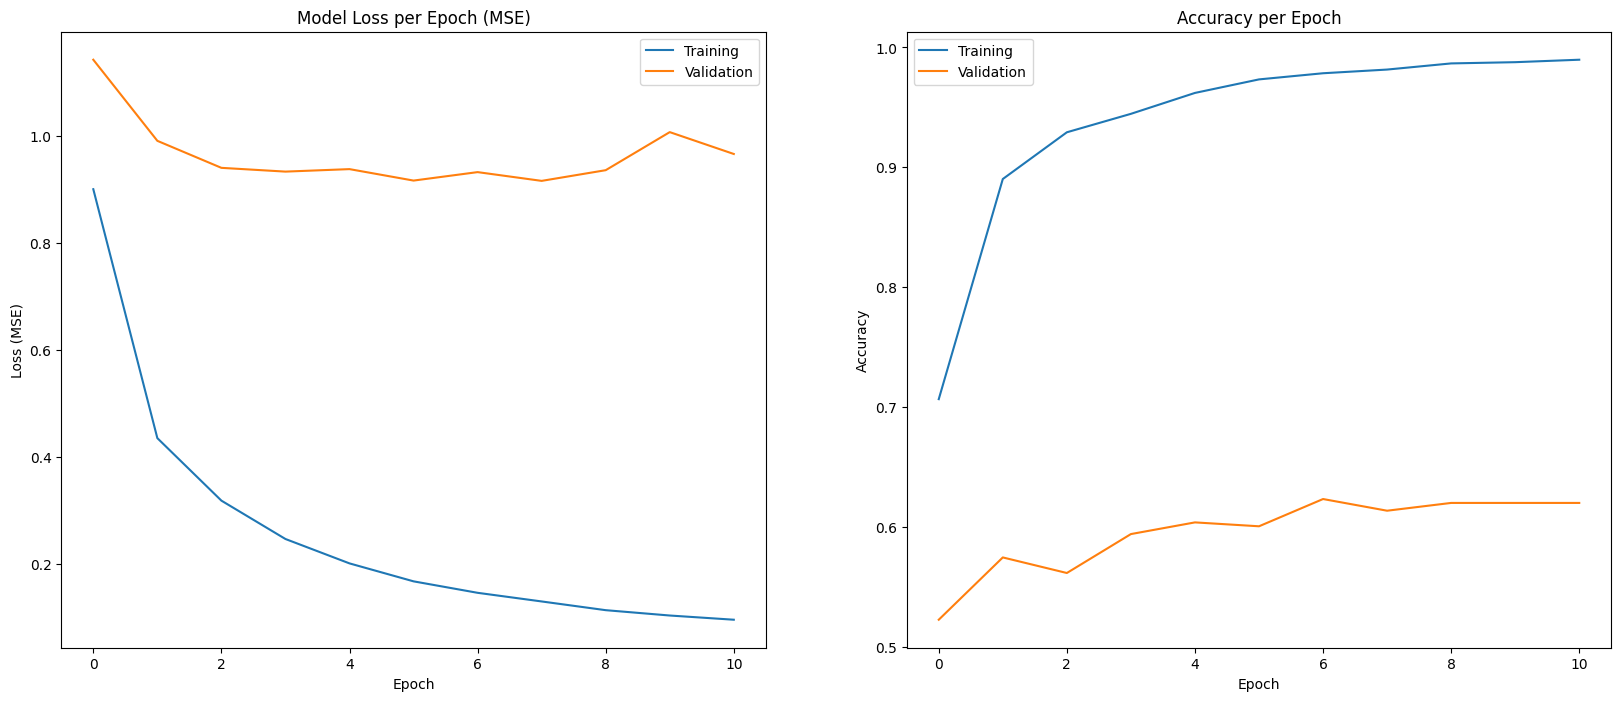

In [20]:
plot_training(model_history)


In [21]:
y_true, y_pred = get_predictions_and_labels(model_X, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.79      0.52      0.63        21
           1       0.85      0.81      0.83        21
           2       0.52      0.81      0.63        21
           3       0.77      1.00      0.87        20
           4       0.70      0.35      0.47        20

    accuracy                           0.70       103
   macro avg       0.72      0.70      0.68       103
weighted avg       0.72      0.70      0.69       103



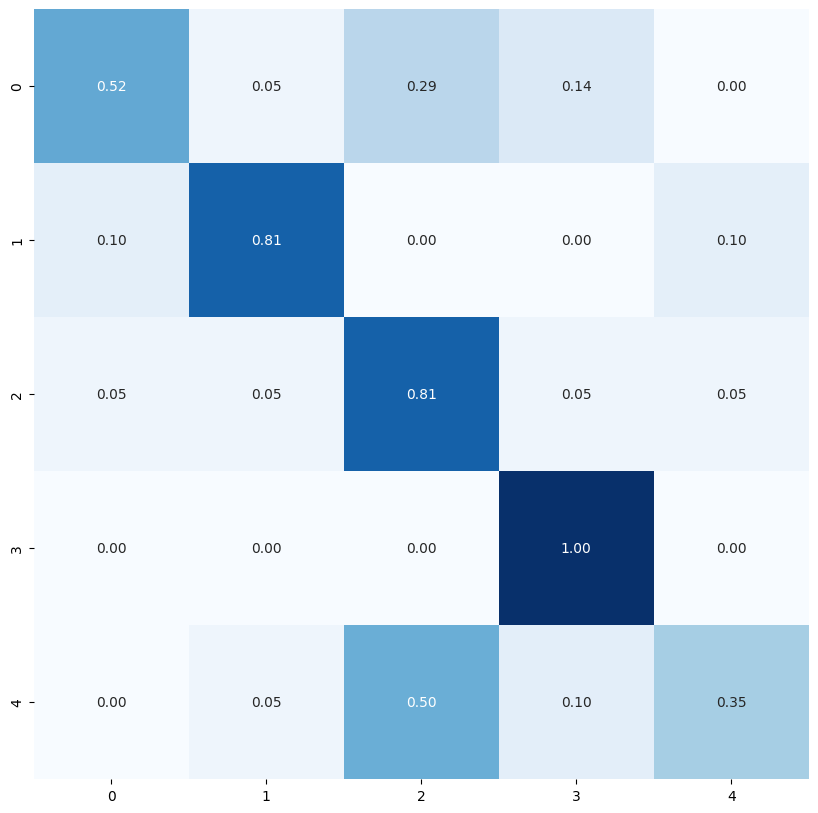

In [22]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


In [24]:
print('Class names:')
print(sorted(os.listdir(train_dir)))


Class names:
['bent_lead', 'cut_lead', 'damaged_case', 'good', 'misplaced']


In [25]:
model_X.save('/content/drive/My Drive/Colab Notebooks/cnn_xception.keras')
model_X.save_weights('/content/drive/My Drive/Colab Notebooks/cnn_xception.weights.h5')


In [ ]:
#import keras

#model_X = keras.saving.load_model('/content/drive/My Drive/Colab Notebooks/cnn_xception.keras')

In [32]:
# Take images from holdout set

class_names = sorted(os.listdir(holdout_dir))

# Get a single batch from the test dataset.
# The images in test_ds are already preprocessed by VGG16's preprocess_input
# and are of float32 dtype.
images_batch, labels_batch = next(iter(test_ds))

# Select the first 4 images and their corresponding labels from the batch.
# images will now be float32, as expected by the model
images = images_batch.numpy()[:4]
labels = labels_batch.numpy()[:4]

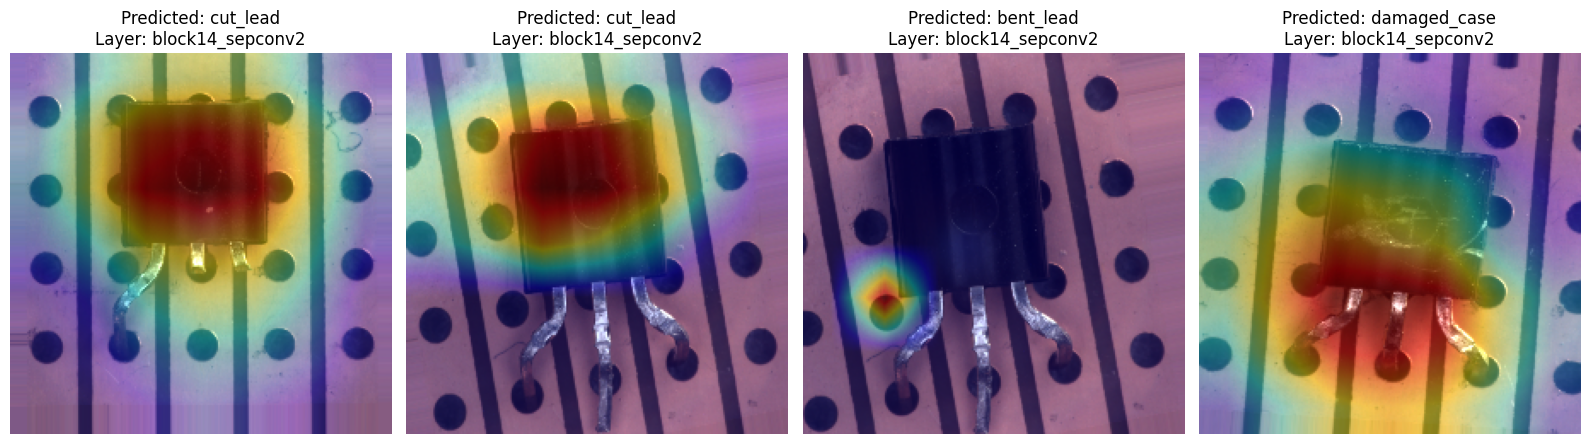

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def deprocess_xception(x):
    # Reverses the preprocessing done by tf.keras.applications.xception.preprocess_input
    # x is scaled to [-1, 1]
    x = x.copy()
    x = x * 127.5 + 127.5 # Rescale from [-1, 1] to [0, 255]
    x = np.clip(x, 0, 255).astype('uint8')
    return x

def show_grad_cam_cnn(images, model, class_names):
    number_of_images = images.shape[0]

    # Assume the base model (Xception) is the first layer of the functional model
    if isinstance(model.layers[0], tf.keras.Model):
        base_model = model.layers[0]
        # Xception primarily uses SeparableConv2D layers
        conv_layers = [layer.name for layer in base_model.layers if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.SeparableConv2D))]
    else:
        # Fallback if the base model is not the first layer or directly accessible this way
        conv_layers = [layer.name for layer in model.layers if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.SeparableConv2D))]

    if conv_layers:
        # Get the last convolutional layer for Grad-CAM
        target_conv_layer = conv_layers[-1]
    else:
        print("No convolutional layers found in the base model.")
        return

    plt.figure(figsize=(4 * number_of_images, 5))

    for i in range(number_of_images):
        # Use the correct deprocessing function for Xception
        original_image_display = deprocess_xception(images[i])

        # Get the heatmap and predicted class from grad_cam function
        heatmap, predicted_class_idx = grad_cam(images[i], model, target_conv_layer)
        predicted_class_name = class_names[predicted_class_idx]

        # Convert heatmap to RGB
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        # Superimpose the heatmap on the original image
        superimposed_img = heatmap * 0.4 + original_image_display
        superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

        # Plotting
        plt.subplot(1, number_of_images, i + 1)
        plt.imshow(superimposed_img)
        plt.title(f'Predicted: {predicted_class_name}\nLayer: {target_conv_layer}')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the modified function
show_grad_cam_cnn(images, model_X, class_names)

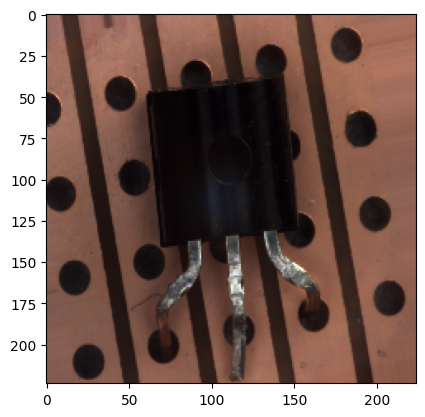

In [34]:
plt.imshow(deprocess_xception(images[1]))